# Лабораторная работа № 3
## «Численное интегрирование»

**Вариант:** 11  
**Выполнил:** Стаселько Илья

### Постановка задачи
Написать программу вычисления определенного интеграла:
$$ I = \int_0^4 \frac{e^x - \cos x}{x} dx $$
используя составные квадратурные формулы (КФ трапеций и КФ Симпсона), а также квадратурную формулу Гаусса-Лежандра с $k=6$ узлами.

1. С помощью составных КФ вычислить интеграл с заданной точностью $\varepsilon = 10^{-7}$, используя правило Рунге (с двойным пересчетом) для оценки погрешности.
2. Найти точное значение интеграла $I$ численно с помощью сторонней библиотеки с точностью $\varepsilon = 10^{-15}$.
3. Результаты вычислений для составных КФ оформить в виде таблицы.
4. Построить совмещенный график зависимости фактической погрешности от числа разбиений $N_k$ в логарифмическом масштабе. Сравнить теоретический порядок точности $p$ с практическим $p_k$.
5. Привести приближенное значение интеграла по КФ Гаусса-Лежандра ($k=6$) и сравнить с точным значением.

### Краткие теоретические сведения

**1. Особенность подынтегральной функции:**
Функция $f(x) = \frac{e^x - \cos x}{x}$ не определена в точке $x = 0$. Однако предел существует:
$$ \lim_{x \to 0} \frac{e^x - \cos x}{x} = \lim_{x \to 0} \frac{(1 + x + \dots) - (1 - x^2/2 + \dots)}{x} = 1 $$
Поэтому я доопределю функцию $f(0) = 1$.

**2. Составные квадратурные формулы (КФ):**
Отрезок интегрирования $[a, b]$ разбивается на $N$ равных частей с шагом $h = \frac{b - a}{N}$.

*   **КФ трапеций** (теоретический порядок точности $p = 2$):
    $$ I_{трс} \approx h \left( \frac{f(x_0) + f(x_N)}{2} + \sum_{i=1}^{N-1} f(x_i) \right) $$

*   **КФ Симпсона (парабол)** (теоретический порядок точности $p = 4$, $N$ — четное):
    $$ I_{симп} \approx \frac{h}{3} \left( f(x_0) + 4 \sum_{i=1, 3, \dots}^{N-1} f(x_i) + 2 \sum_{i=2, 4, \dots}^{N-2} f(x_i) + f(x_N) \right) $$

**3. Правило Рунге для оценки погрешности:**
Для оценки погрешности вычислений по сетке с шагом $h$ используется результат на сетке с шагом $2h$ (вдвое меньше разбиений):
$$ R_h \approx \frac{|I_h - I_{2h}|}{2^p - 1} $$
где $p$ — теоретический порядок точности метода. Вычисления продолжаются (путем удвоения $N$), пока $R_h < \varepsilon$.

**4. Практический порядок точности:**
$$ p_k = \frac{\lg(R_{h_{k-1}} / R_{h_k})}{\lg 2} $$
где $R_{h_k} = |I - S_{h_k}|$ — фактическая погрешность (отклонение от точного значения $I$).

**5. КФ Гаусса-Лежандра:**
Обладает наивысшей алгебраической степенью точности ($2k-1$). Для отрезка $[-1, 1]$ узлы $t_i$ — корни полинома Лежандра степени $k$, а веса $A_i$ вычисляются аналитически. Для произвольного отрезка $[a, b]$ делается замена переменных:
$$ x = \frac{b - a}{2}t + \frac{a + b}{2}, \quad dx = \frac{b - a}{2}dt $$
$$ \int_a^b f(x)dx \approx \frac{b - a}{2} \sum_{i=1}^k A_i f(x_i) $$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings
from scipy.integrate import IntegrationWarning

warnings.filterwarnings("ignore", category=IntegrationWarning)

# Параметры задачи
a = 0.0
b = 4.0
eps_target = 1e-7

# Подынтегральная функция с доопределением в нуле
def f(x):
    x = np.asarray(x)
    res = np.zeros_like(x, dtype=float)
    
    # Маска для ненулевых значений x (защита от деления на ноль и близких к нему чисел)
    mask = np.abs(x) > 1e-14
    
    res[mask] = (np.exp(x[mask]) - np.cos(x[mask])) / x[mask]
    res[~mask] = 1.0 # Значение предела при x -> 0
    
    return res if res.ndim > 0 else res.item()

# 1. Нахожу точное значение интеграла с помощью scipy.integrate.quad
# Требую точность (~1e-15)
I_exact, exact_err = quad(f, a, b, epsabs=1e-15, epsrel=1e-15)

print(f"Точное значение интеграла I: {I_exact:.15f}")
print(f"Оценка погрешности scipy: {exact_err:.3e}")

Точное значение интеграла I: 19.771856167943149
Оценка погрешности scipy: 2.195e-13


### Реализация составных квадратурных формул

In [3]:
"""Составная КФ трапеций"""
def trapezoidal_rule(f, a, b, N):
    x = np.linspace(a, b, N + 1)
    y = f(x)
    h = (b - a) / N
    integral = h * (0.5 * y[0] + 0.5 * y[-1] + np.sum(y[1:-1]))
    return integral

"""Составная КФ Симпсона (N должно быть четным)"""
def simpson_rule(f, a, b, N):
    if N % 2 != 0:
        raise ValueError("Для метода Симпсона N должно быть четным.")
    x = np.linspace(a, b, N + 1)
    y = f(x)
    h = (b - a) / N
    
    sum_odd = np.sum(y[1:-1:2])
    sum_even = np.sum(y[2:-2:2])
    
    integral = (h / 3) * (y[0] + 4 * sum_odd + 2 * sum_even + y[-1])
    return integral

"""Функция для проведения эксперимента с двойным пересчетом (правило Рунге)"""
def run_integration_experiment(method, p, start_N=4):
    results =[]
    N = start_N
    
    # Делаю вычисление для начального N
    I_prev = method(f, a, b, N)
    
    # Добавляю первую запись (нет данных для Рунге и pk)
    actual_err = abs(I_exact - I_prev)
    results.append({
        'N': N,
        'h': (b - a) / N,
        'I_h': I_prev,
        'Runge_err': None,
        'Actual_err': actual_err,
        'p_k': None
    })
    
    # Удваиваю шаги, пока не достигну нужной точности по Рунге
    while True:
        N *= 2
        I_curr = method(f, a, b, N)
        
        # Оценка по Рунге
        runge_err = abs(I_curr - I_prev) / (2**p - 1)
        
        # Фактическая ошибка
        actual_err = abs(I_exact - I_curr)
        
        # Практический порядок точности (p_k)
        prev_actual_err = results[-1]['Actual_err']
        if actual_err > 0 and prev_actual_err > 0:
            p_k = np.log10(prev_actual_err / actual_err) / np.log10(2)
        else:
            p_k = None
            
        results.append({
            'N': N,
            'h': (b - a) / N,
            'I_h': I_curr,
            'Runge_err': runge_err,
            'Actual_err': actual_err,
            'p_k': p_k
        })
        
        if runge_err < eps_target:
            break
            
        I_prev = I_curr
        
    return pd.DataFrame(results)

df_trap = run_integration_experiment(trapezoidal_rule, p=2)
df_simp = run_integration_experiment(simpson_rule, p=4)

### Таблица результатов вычислений

In [4]:
# Объединяю таблицы для вывода
df_trap['Формула'] = 'КФ Трапеций'
df_simp['Формула'] = 'КФ Симпсона'

df_combined = pd.concat([df_trap, df_simp])

# Переставляю колонки для соответствия заданию
cols =['Формула', 'N', 'h', 'I_h', 'Runge_err', 'Actual_err', 'p_k']
df_combined = df_combined[cols]

df_combined.columns =[
    'КФ', 'Разбиения (N)', 'Шаг (h)', 'Интеграл S_h', 
    'Погрешность Рунге', 'Факт. погрешность |I - S_h|', 'Практ. порядок (p_k)'
]

pd.set_option('display.float_format', lambda x: f'{x:.5e}' if abs(x) < 1e-4 and x != 0 else f'{x:.8f}')
display(df_combined.set_index(['КФ', 'Разбиения (N)']))

Шаг (h)  Интеграл S_h  Погрешность Рунге  \
КФ          Разбиения (N)                                               
КФ Трапеций 4             1.00000000   20.51223167                NaN   
            8             0.50000000   19.95885773         0.18445798   
            16            0.25000000   19.81872762         0.04671003   
            32            0.12500000   19.78358163         0.01171533   
            64            0.06250000   19.77478801         0.00293121   
            128           0.03125000   19.77258916         0.00073295   
            256           0.01562500   19.77203942         0.00018325   
            512           0.00781250   19.77190198        4.58123e-05   
            1024          0.00390625   19.77186762        1.14531e-05   
            2048          0.00195312   19.77185903        2.86328e-06   
            4096          0.00097656   19.77185688        7.15820e-07   
            8192          0.00048828   19.77185635        1.78955e-07   
            16384         0.00024414   19.77185621        4.47387e-08   
КФ Симпсона 4             1.00000000   19.81025844                NaN   
            8             0.50000000   19.77439975         0.00239058   
            16            0.25000000   19.77201759         0.00015881   
            32            0.12500000   19.77186630        1.00862e-05   
            64            0.06250000   19.77185680        6.32956e-07   
            128           0.03125000   19.77185621        3.96001e-08   

                           Факт. погрешность |I - S_h|  Практ. порядок (p_k)  
КФ          Разбиения (N)                                                     
КФ Трапеций 4                               0.74037550                   NaN  
            8                               0.18700156            1.98520686  
            16                              0.04687146            1.99626879  
            32                              0.01172546            1.99906509  
            64                              0.00293184            1.99976614  
            128                             0.00073299            1.99994153  
            256                             0.00018325            1.99998538  
            512                            4.58124e-05            1.99999635  
            1024                           1.14531e-05            1.99999909  
            2048                           2.86328e-06            1.99999977  
            4096                           7.15820e-07            1.99999994  
            8192                           1.78955e-07            1.99999998  
            16384                          4.47388e-08            1.99999991  
КФ Симпсона 4                               0.03840228                   NaN  
            8                               0.00254358            3.91626078  
            16                              0.00016142            3.97795567  
            32                             1.01279e-05            3.99441750  
            64                             6.33611e-07            3.99859987  
            128                            3.96103e-08            3.99964969

### График зависимости погрешности от числа разбиений

Построю совмещенный график зависимости фактической погрешности от числа разбиений $N$ в логарифмическом масштабе по обеим осям.

**Теория:** Ошибка метода имеет вид $R \approx C \cdot h^p$. Так как $h \sim 1/N$, то $R \approx C \cdot N^{-p}$.

Если прологарифмировать обе части: $\log R = \log C - p \log N$.

Это уравнение прямой линии $y = b - px$.

### Построение опорного наклона

Погрешность метода $R$ убывает пропорционально числу разбиений $N$ в степени $p$ (где $p$ — теоретический порядок точности метода):
$$ R \approx C \cdot N^{-p} $$

Чтобы эталонная (пунктирная) линия на графике исходила точно из первой точки практических вычислений, надо найти константу $C$. Обозначу стартовую погрешность как $R_0$, а стартовое число разбиений как $N_0$. Тогда:
$$ R_0 = C \cdot N_0^{-p} \implies C = R_0 \cdot N_0^p $$

Подставив найденную константу $C$ обратно в исходную формулу, получу итоговое уравнение для эталонной линии:
$$ R = R_0 \cdot \left( \frac{N_0}{N} \right)^p $$

Именно эта зависимость запрограммирована при построении графиков:
* Для **КФ трапеций** ($p=2$): используется множитель `(N_ref[0] / N_ref)**2`
* Для **КФ Симпсона** ($p=4$): используется множитель `(N_ref[0] / N_ref)**4`

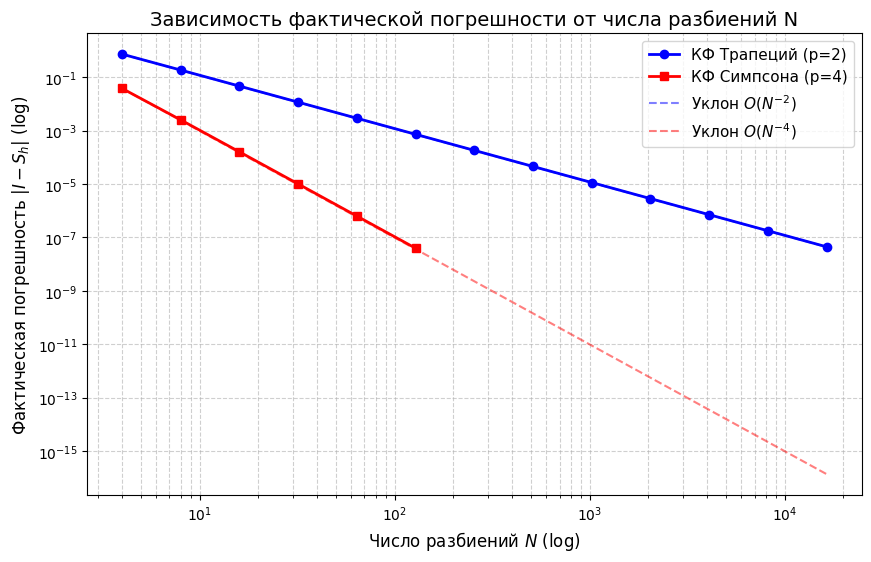

In [5]:
plt.figure(figsize=(10, 6))

plt.loglog(df_trap['N'], df_trap['Actual_err'], 'o-', label='КФ Трапеций (p=2)', color='blue', linewidth=2)
plt.loglog(df_simp['N'], df_simp['Actual_err'], 's-', label='КФ Симпсона (p=4)', color='red', linewidth=2)

# Добавляю эталонные линии наклона для проверки порядка сходимости
N_ref = np.array([df_trap['N'].iloc[0], df_trap['N'].iloc[-1]])
# Опорная линия O(1/N^2)
plt.loglog(N_ref, df_trap['Actual_err'].iloc[0] * (N_ref[0]/N_ref)**2, 'b--', alpha=0.5, label='Уклон $O(N^{-2})$')
# Опорная линия O(1/N^4)
plt.loglog(N_ref, df_simp['Actual_err'].iloc[0] * (N_ref[0]/N_ref)**4, 'r--', alpha=0.5, label='Уклон $O(N^{-4})$')

plt.title('Зависимость фактической погрешности от числа разбиений N', fontsize=14)
plt.xlabel('Число разбиений $N$ (log)', fontsize=12)
plt.ylabel('Фактическая погрешность $|I - S_h|$ (log)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)
plt.show()

### Квадратурная формула Гаусса-Лежандра (k = 6)

Применяю КФ Гаусса с $k=6$ узлами. Из теории известно, что алгебраическая степень точности этого метода равна $2k - 1 = 11$. То есть метод точен для всех полиномов до 11-й степени включительно. Узлы и веса для отрезка $[-1, 1]$ вычисляются с помощью библиотеки `numpy`, после чего переносятся на отрезок $[0, 4]$.

Для весовой функции $p(x) \equiv 1$ на отрезке $[-1, 1]$ ортогональными являются **многочлены Лежандра** $P_k(t)$. Узлы $t_i$ — это корни многочлена Лежандра $k$-й степени:
$$ P_6(t) = \frac{1}{16}(231t^6 - 315t^4 + 105t^2 - 5) = 0 $$
Веса квадратурной формулы Гаусса вычисляются так, чтобы интегрирование базисных многочленов Лагранжа было точным. Теоретически они считаются через интеграл:
$$ A_i = \int_{-1}^1 \frac{P_k(t)}{(t - t_i)P'_k(t_i)} dt $$
Для полиномов Лежандра эта формула упрощается до следующего вида:
$$ A_i = \frac{2}{(1 - t_i^2)[P'_k(t_i)]^2} $$
*Библиотека `numpy`, находя собственные значения специальной трехдиагональной матрицы, возвращает готовые массивы узлов и весов.*

In [6]:
k_gauss = 6

# Получаю узлы и веса Лежандра для отрезка[-1, 1]
t_nodes, weights = np.polynomial.legendre.leggauss(k_gauss)

# Переношу узлы на отрезок [a, b]
x_nodes_gauss = (b - a) / 2 * t_nodes + (a + b) / 2

# Вычисляю интеграл
I_gauss = (b - a) / 2 * np.sum(weights * f(x_nodes_gauss))
gauss_actual_err = abs(I_exact - I_gauss)

print(f"Приближенное значение по КФ Гаусса (k={k_gauss}): {I_gauss:.15f}")
print(f"Точное значение I:                           {I_exact:.15f}")
print(f"Фактическая погрешность метода Гаусса:       {gauss_actual_err:.3e}")

Приближенное значение по КФ Гаусса (k=6): 19.771856160399985
Точное значение I:                           19.771856167943149
Фактическая погрешность метода Гаусса:       7.543e-09


### Выводы

На основе проведенного вычислительного эксперимента можно сделать следующие выводы:

1. **Достоверность правила Рунге:** Оценка погрешности по правилу Рунге согласуется с фактической погрешностью (отклонением от точного значения). Погрешность Рунге дает гарантированный критерий остановки для достижения заданной точности $\varepsilon = 10^{-7}$.
2. **Анализ сходимости КФ Трапеций:** Для КФ трапеций теоретический порядок точности $p=2$. Значения в колонке "Практический порядок ($p_k$)" стабильно держатся около $2.0$. На графике сходимости линия метода трапеций идет параллельно опорной линии $O(N^{-2})$. Для достижения требуемой точности потребовалось $N = 16384$ разбиений.
3. **Анализ сходимости КФ Симпсона:** Для КФ Симпсона теоретический порядок точности $p=4$. Вычисленный практический порядок $p_k$ также близок к $4.0$. Метод Симпсона сходится значительно быстрее метода трапеций (график имеет гораздо более крутой наклон $O(N^{-4})$). Заданная точность $\varepsilon = 10^{-7}$ была достигнута всего за $N = 128$ разбиений.
4. **Эффективность КФ Гаусса-Лежандра:** Метод Гаусса показал высокую точность. Используя всего $k=6$ узлов (и, соответственно, всего 6 вычислений подынтегральной функции), метод Гаусса обеспечил погрешность порядка $10^{-7} \dots 10^{-8}$. Для сравнения, методу Симпсона для такой же точности понадобилось 129 вызовов функции (128 разбиения), а методу трапеций — 16385 вызовов. Это подтверждает теоретический факт, что для гладких функций ортогональные многочлены (метод Гаусса) обеспечивают наилучшее соотношение количества вычислений и достигаемой точности.